In [5]:
# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA

Machine Learning para Classificação de Câncer de Mama

In [6]:
pd.set_option('display.max_columns', None)

# Carregamento dos dados e amostras

In [7]:
df = pd.read_csv("../data/breast-cancer-wisconsin-data.csv")

In [8]:
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape: 569 rows × 33 columns


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [9]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,1.1760,1.256,7.673,158.70,0.010300,0.02891,0.05198,0.02454,0.01114,0.004239,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,0.7655,2.463,5.203,99.04,0.005769,0.02423,0.03950,0.01678,0.01898,0.002498,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,0.4564,1.075,3.425,48.55,0.005903,0.03731,0.04730,0.01557,0.01318,0.003892,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,0.7260,1.595,5.772,86.22,0.006522,0.06158,0.07117,0.01664,0.02324,0.006185,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,0.3857,1.428,2.548,19.15,0.007189,0.00466,0.00000,0.00000,0.02676,0.002783,9.456,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [10]:
print("Formato:", df.shape)
print("Colunas:", list(df.columns))

Formato: (569, 33)
Colunas: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32']


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

In [12]:
# Resumo estatístico
df.describe().T.style.background_gradient(cmap='Blues')

,count,mean,std,min,25%,50%,75%,max
id,569.000000,30371831.432337,125020585.612224,8670.000000,869218.000000,906024.000000,8813129.000000,911320502.000000
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000


In [13]:
# Valores em falta / nulos
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({"Qtd. de Nulos": missing, "Nulos %": missing_pct})
missing_df = missing_df[missing_df["Qtd. de Nulos"] > 0].sort_values("Qtd. de Nulos", ascending=False)

print(f"Total de valores em nulos no dataset: {df.isnull().sum().sum()}")
missing_df


Total de valores em nulos no dataset: 569


,Qtd. de Nulos,Nulos %
Unnamed: 32,569,100.0


In [14]:
# Linhas duplicadas
duplicate_count = df.duplicated().sum()
print(f"Número de linhas duplicadas: {duplicate_count}")

Número de linhas duplicadas: 0


diagnosis
B    357
M    212
Name: count, dtype: int64

Class balance: {'B': 62.7, 'M': 37.3}


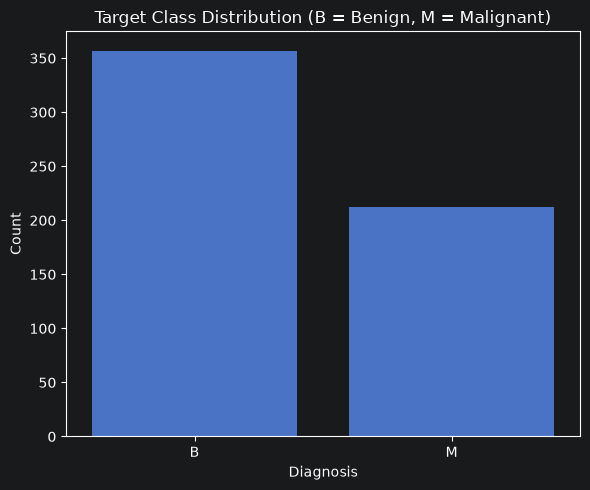

In [15]:
# Distribuição por classes
class_counts = df["diagnosis"].value_counts()
print(class_counts)
print(f"\nClass balance: {(class_counts / class_counts.sum() * 100).round(1).to_dict()}")

plt.figure(figsize=(6, 5))
sns.countplot(data=df, x="diagnosis", order=["B", "M"])
plt.title("Target Class Distribution (B = Benign, M = Malignant)")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

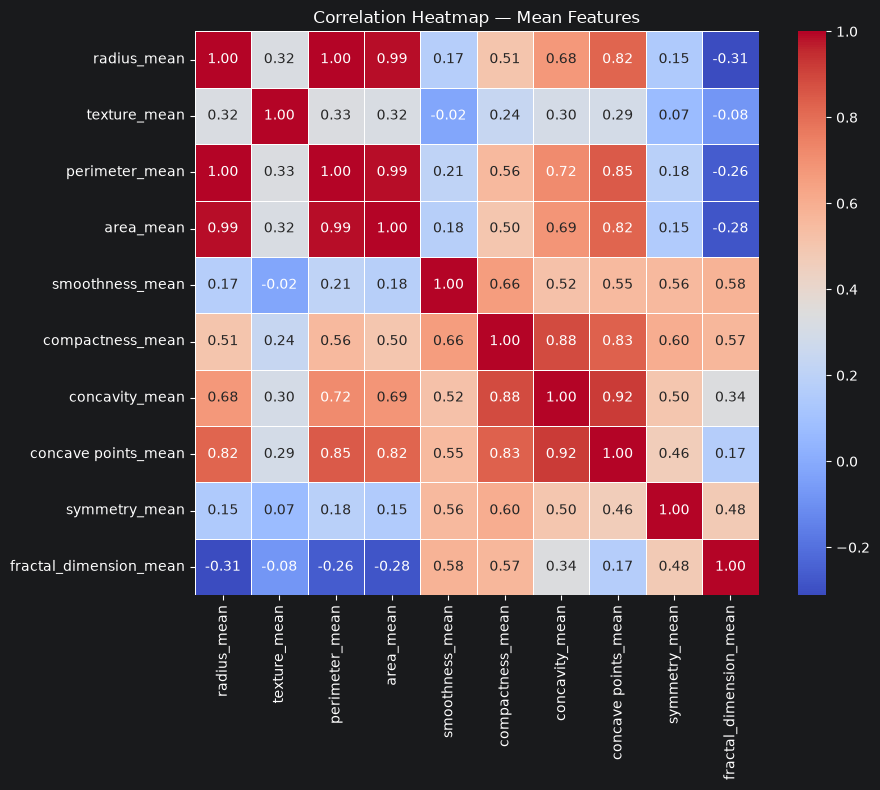

In [16]:
# Correlation Heatmap (Mean Features)
mean_features = [c for c in df.columns if c.endswith("_mean")]

plt.figure(figsize=(10, 8))
corr = df[mean_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, square=True)
plt.title("Correlation Heatmap — Mean Features")
plt.tight_layout()
plt.show()


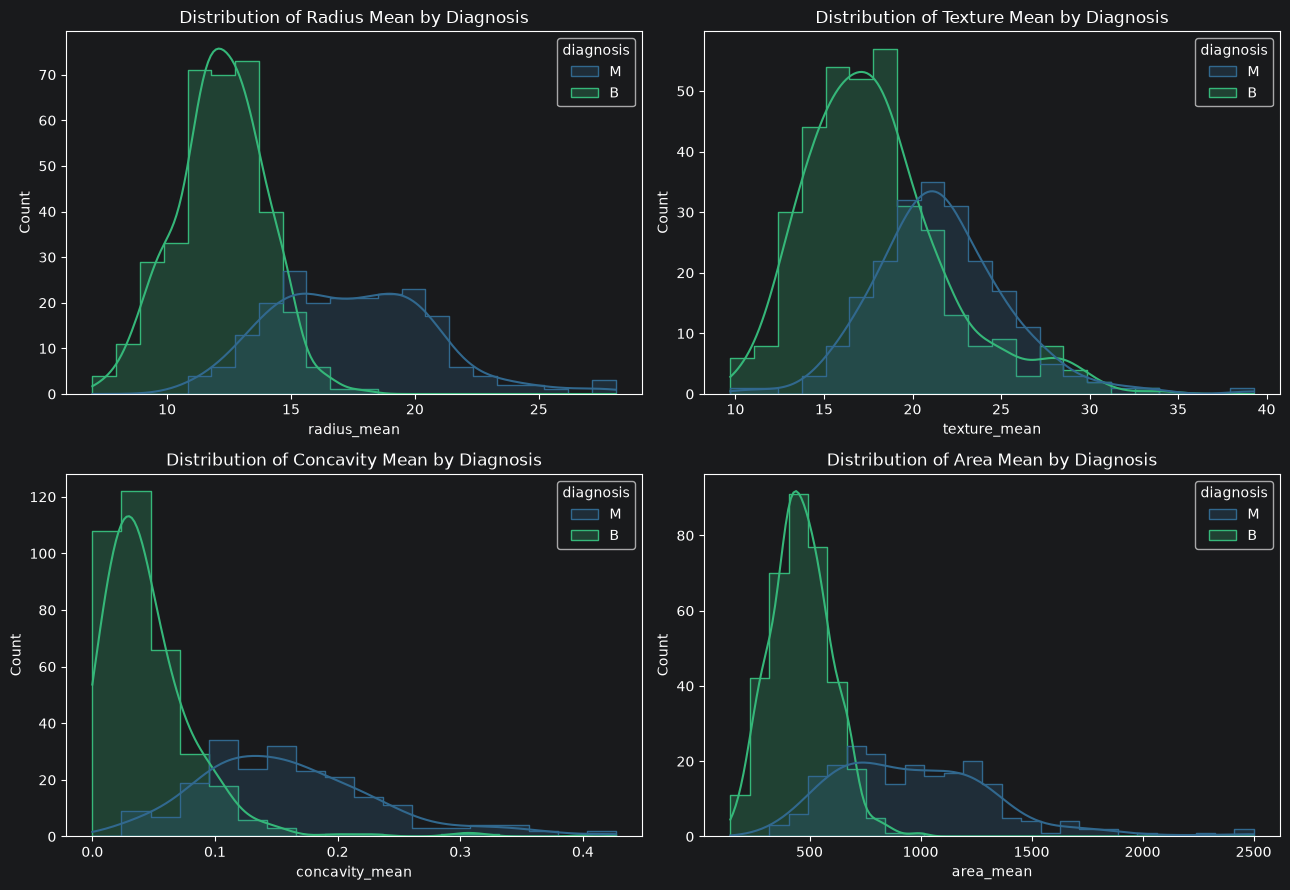

In [17]:
# Distribuições das características por diagnóstico
key_features = ["radius_mean", "texture_mean", "concavity_mean", "area_mean"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), key_features):
    sns.histplot(data=df, x=col, hue="diagnosis", kde=True, palette="viridis", element="step", ax=ax)
    ax.set_title(f"Distribution of {col.replace('_', ' ').title()} by Diagnosis")

plt.tight_layout()
plt.show()

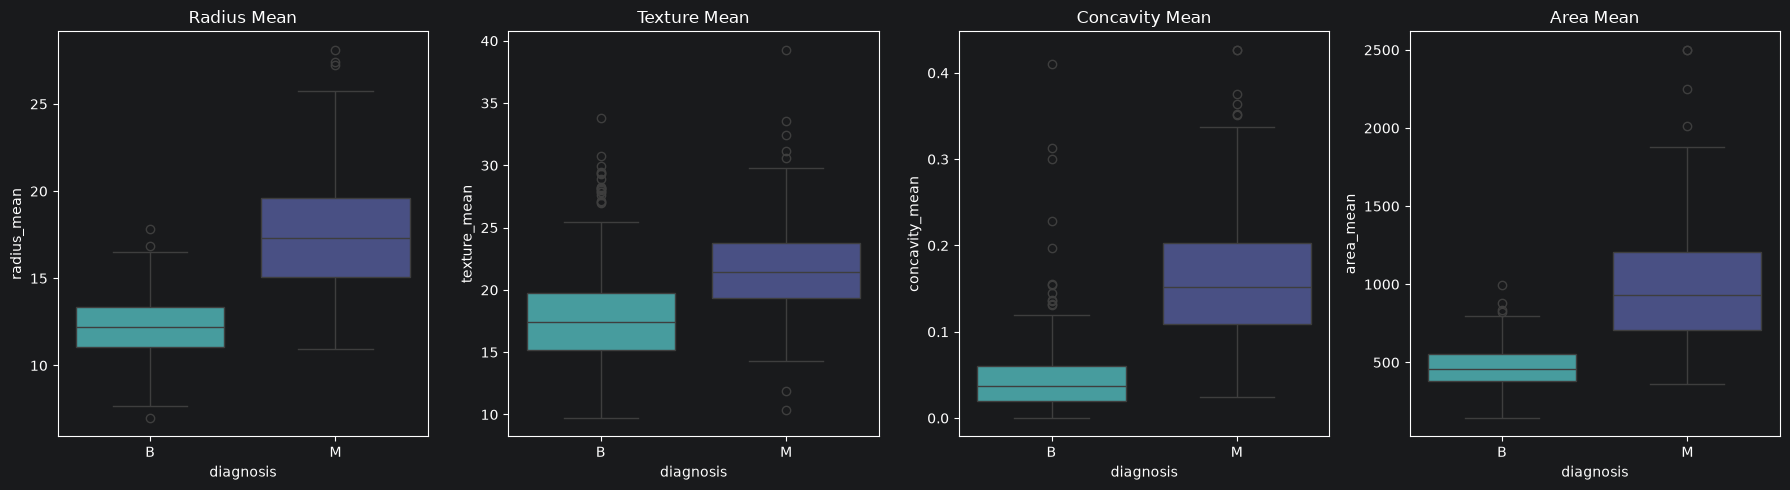

In [18]:
# Boxplots
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, col in zip(axes, key_features):
    sns.boxplot(data=df, x="diagnosis", y=col, order=["B", "M"], hue="diagnosis", palette="mako", ax=ax)
    ax.set_title(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

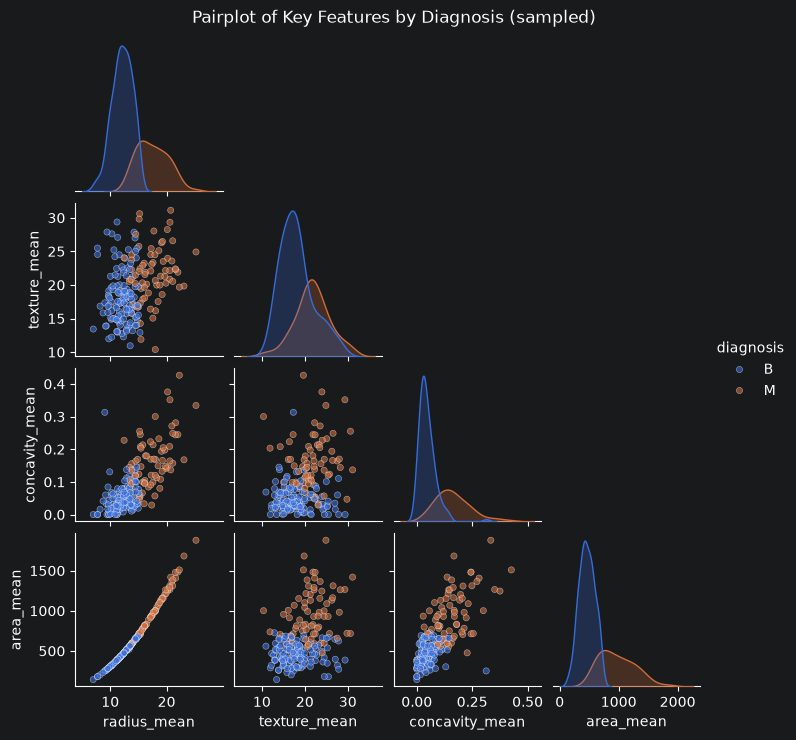

In [19]:
# Pairplot
pair_cols = ["radius_mean", "texture_mean", "concavity_mean", "area_mean", "diagnosis"]
sample_df = df[pair_cols].sample(min(200, len(df)), random_state=42)

sns.pairplot(sample_df, hue="diagnosis", corner=True,
             height=1.8, plot_kws={"alpha": 0.6, "s": 20})
plt.suptitle("Pairplot of Key Features by Diagnosis (sampled)", y=1.02)
plt.show()

In [20]:
# Lindando os dados
df.drop(['Unnamed: 32','id'],  axis=1,inplace=True)

# Encode target: maligno = 1 (classe positiva), benigno = 0
label_encoder = LabelEncoder()
df["diagnosis"] = label_encoder.fit_transform(df["diagnosis"])  # B=0, M=1

print(f"Dataset shape (Current): {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset shape (Current): 569 rows × 31 columns


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [21]:
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [22]:
# Feature Engineering

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Feature matrix X:", X.shape)
print("Target vector y :", y.shape)
print(f"Positive class (malignant) rate: {y.mean():.2%}")


Feature matrix X: (569, 30)
Target vector y : (569,)
Positive class (malignant) rate: 37.26%


In [23]:
# Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]:,} rows  |  Malignant rate: {y_train.mean():.2%}")
print(f"Test set    : {X_test.shape[0]:,} rows  |  Malignant rate: {y_test.mean():.2%}")


Training set: 455 rows  |  Malignant rate: 37.36%
Test set    : 114 rows  |  Malignant rate: 36.84%


In [24]:
# Feature Scaling
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test), columns=X_test.columns, index=X_test.index
)

print(" Features scaled. Example — before vs. after for 'area_mean':")
print(f"   Before: mean={X_train['area_mean'].mean():.2f}, std={X_train['area_mean'].std():.2f}")
print(f"   After : mean={X_train_scaled['area_mean'].mean():.2f}, std={X_train_scaled['area_mean'].std():.2f}")

 Features scaled. Example — before vs. after for 'area_mean':
   Before: mean=659.58, std=360.42
   After : mean=-0.00, std=1.00


In [25]:
# Avaliação de modelos
results = []  # recolhe um dicionário por modelo

def evaluate_metrics(model, model_name, X_test, y_test, results_list=results):
    """
    Avalia um modelo já treinado e exibe suas métricas.
    """

    # Predições
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = y_pred

    # Métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    # Salvar resultados
    results_list.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    # Exibir resultados
    print(f"📌 {model_name}")
    print(f"Accuracy  : {accuracy:.4f}")
    print(f"Precision : {precision:.4f}")
    print(f"Recall    : {recall:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)
    print("-" * 50)

In [26]:
# Model Training

# 1º Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=5000)
log_reg.fit(X_train_scaled, y_train)

evaluate_metrics(log_reg, "Logistic Regression", X_test_scaled, y_test)

📌 Logistic Regression
Accuracy  : 0.9649
Precision : 0.9750
Recall    : 0.9286
F1 Score  : 0.9512
ROC-AUC   : 0.9960
Confusion Matrix:
[[71  1]
 [ 3 39]]
--------------------------------------------------


In [27]:
# 2º Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

evaluate_metrics(rf, "Random Forest", X_test_scaled, y_test)

📌 Random Forest
Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9286
F1 Score  : 0.9630
ROC-AUC   : 0.9929
Confusion Matrix:
[[72  0]
 [ 3 39]]
--------------------------------------------------


In [28]:
# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

evaluate_metrics(knn, "K-Nearest Neighbors", X_test_scaled, y_test)

📌 K-Nearest Neighbors
Accuracy  : 0.9561
Precision : 0.9744
Recall    : 0.9048
F1 Score  : 0.9383
ROC-AUC   : 0.9823
Confusion Matrix:
[[71  1]
 [ 4 38]]
--------------------------------------------------


In [29]:
# Model Comparison
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values("Accuracy", ascending=False).reset_index(drop=True)
comparison_df.index += 1

comparison_df.style.background_gradient(
    subset=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"], cmap="Greens"
).format({"Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}",
          "F1 Score": "{:.4f}", "ROC-AUC": "{:.4f}"})

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.9737,1.0000,0.9286,0.9630,0.9929
2,Logistic Regression,0.9649,0.9750,0.9286,0.9512,0.9960
3,K-Nearest Neighbors,0.9561,0.9744,0.9048,0.9383,0.9823


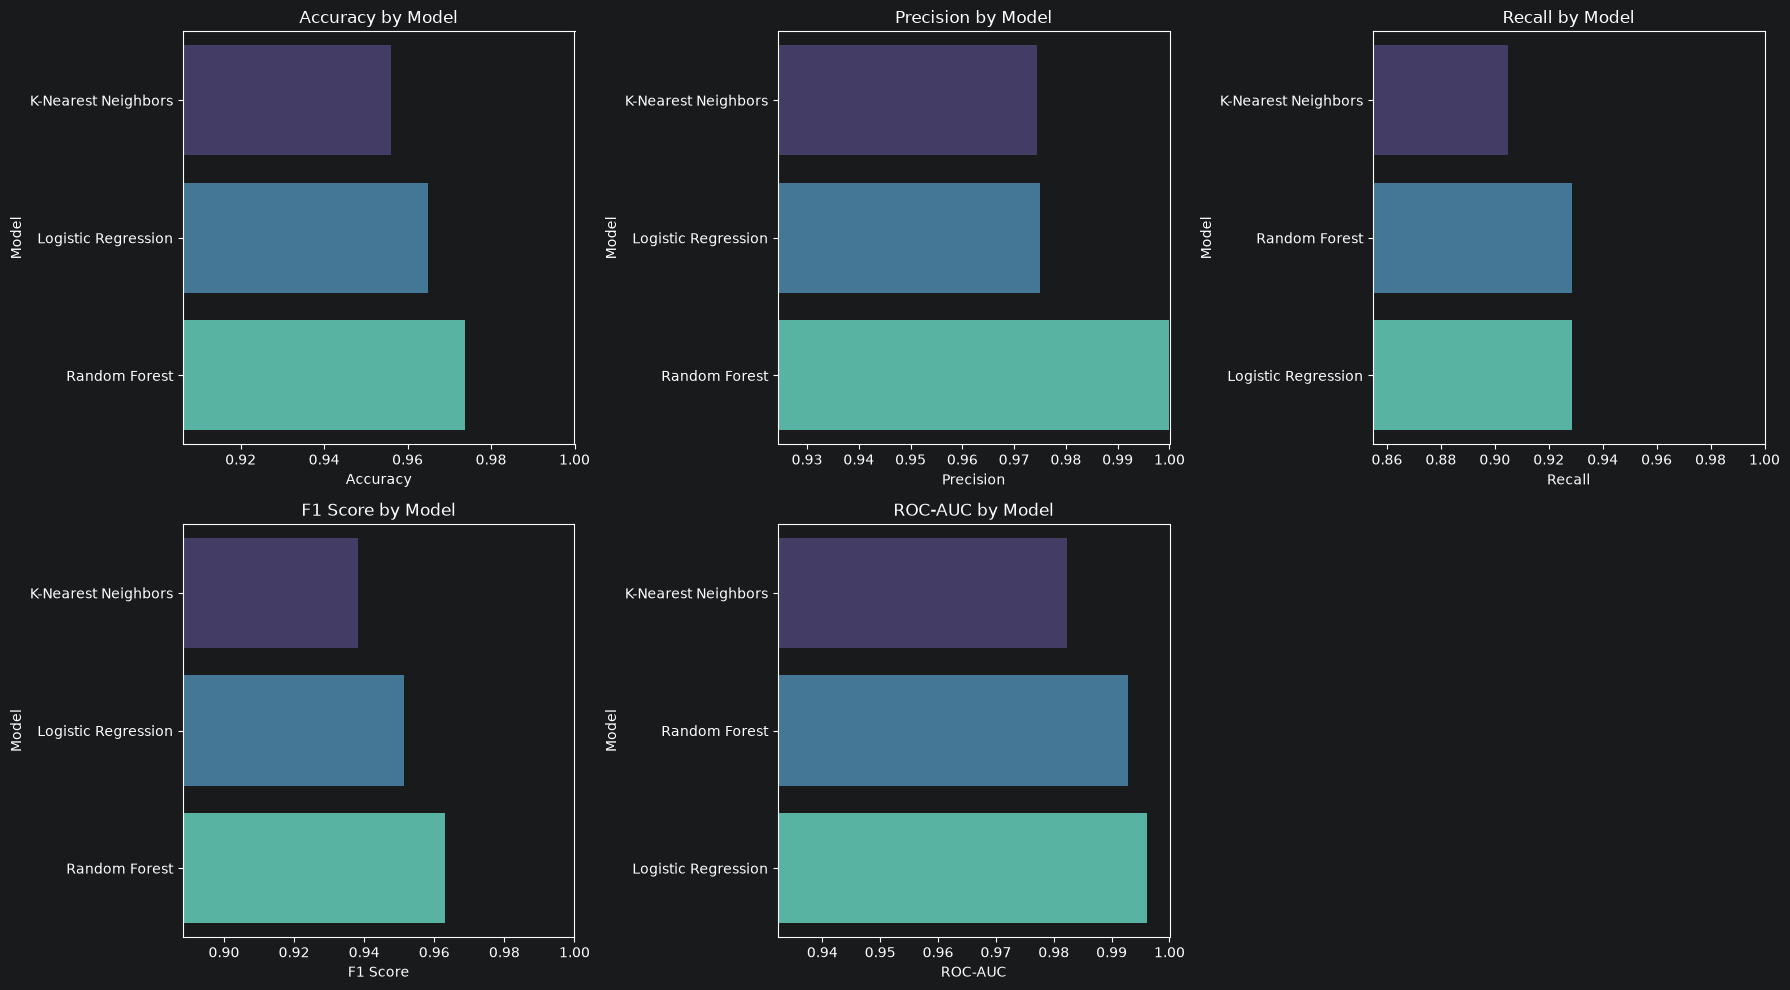

In [30]:
#Metric Comparison Bar Charts
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics_list = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

for ax, metric in zip(axes.flatten(), metrics_list):
    sorted_df = comparison_df.sort_values(metric, ascending=True)
    sns.barplot(data=sorted_df, x=metric, y="Model", hue="Model", palette="mako", legend=False, ax=ax)
    ax.set_title(f"{metric} by Model")
    ax.set_xlim(sorted_df[metric].min() - 0.05, 1.0)

axes.flatten()[-1].axis("off")  # unused 6th subplot
plt.tight_layout()
plt.show()

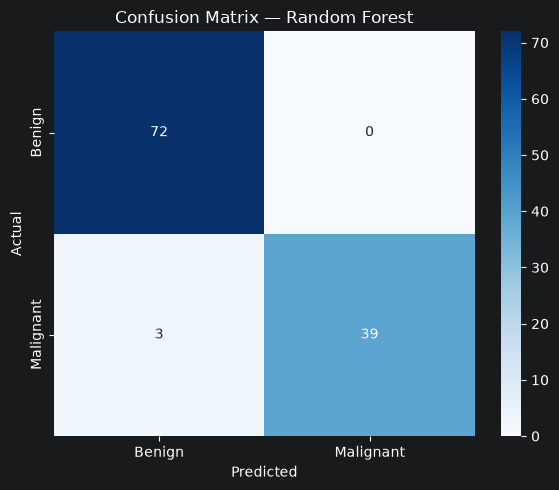

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [31]:
log_pred = log_reg.predict(X_test_scaled)
log_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

rf_pred = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
best_model_name = comparison_df.iloc[0]["Model"]
pred_lookup = {
    "Logistic Regression": log_pred, "Random Forest": rf_pred,
}
proba_lookup = {
    "Logistic Regression": log_proba, "Random Forest": rf_proba,
}
best_pred = pred_lookup[best_model_name]
best_proba = proba_lookup[best_model_name]

cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Benign", "Malignant"], yticklabels=["Benign", "Malignant"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_pred, target_names=["Benign", "Malignant"]))


In [32]:
# Normalização robusta baseada na mediana
robust_scaler = RobustScaler()

X_train_robust = pd.DataFrame(
    robust_scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_robust = pd.DataFrame(
    robust_scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Dados normalizados utilizando mediana/IQR.")
print("Treino:", X_train_robust.shape)
print("Teste :", X_test_robust.shape)

Dados normalizados utilizando mediana/IQR.
Treino: (455, 30)
Teste : (114, 30)


In [33]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_robust)
X_test_pca = pca.transform(X_test_robust)

print("Número de componentes originais:", X_train_robust.shape[1])
print("Número de componentes após PCA:", X_train_pca.shape[1])

print(f"Variância explicada: {pca.explained_variance_ratio_.sum():.2%}")

Número de componentes originais: 30
Número de componentes após PCA: 10
Variância explicada: 95.66%


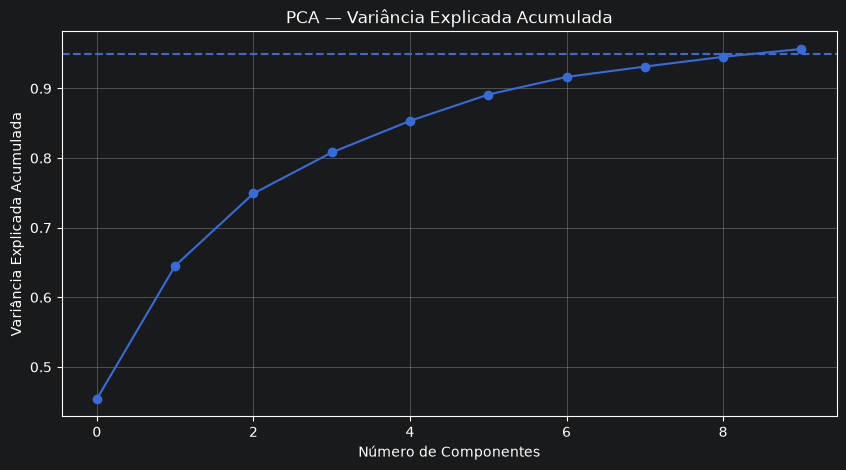

In [34]:
plt.figure(figsize=(10, 5))

plt.plot(
    np.cumsum(pca.explained_variance_ratio_),
    marker="o"
)

plt.axhline(
    y=0.95,
    linestyle="--"
)

plt.xlabel("Número de Componentes")
plt.ylabel("Variância Explicada Acumulada")
plt.title("PCA — Variância Explicada Acumulada")

plt.grid(True)
plt.show()

In [35]:
log_reg_pca = LogisticRegression(
    random_state=42,
    max_iter=5000
)

# Convert PCA arrays to DataFrames with appropriate column names
num_components = X_train_pca.shape[1]
pca_columns = [f'PC{i+1}' for i in range(num_components)]

X_train_pca_df = pd.DataFrame(X_train_pca, columns=pca_columns, index=X_train.index)
X_test_pca_df = pd.DataFrame(X_test_pca, columns=pca_columns, index=X_test.index)

log_reg_pca.fit(
    X_train_pca_df,
    y_train
)

evaluate_metrics(
    log_reg_pca,
    "Logistic Regression + RobustScaler + PCA",
    X_test_pca_df,
    y_test
)


📌 Logistic Regression + RobustScaler + PCA
Accuracy  : 0.9737
Precision : 1.0000
Recall    : 0.9286
F1 Score  : 0.9630
ROC-AUC   : 0.9974
Confusion Matrix:
[[72  0]
 [ 3 39]]
--------------------------------------------------


In [36]:
rf_pca = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_pca.fit(
    X_train_pca_df,
    y_train
)

evaluate_metrics(
    rf_pca,
    "Random Forest + RobustScaler + PCA",
    X_test_pca_df,
    y_test
)

📌 Random Forest + RobustScaler + PCA
Accuracy  : 0.9386
Precision : 0.9487
Recall    : 0.8810
F1 Score  : 0.9136
ROC-AUC   : 0.9854
Confusion Matrix:
[[70  2]
 [ 5 37]]
--------------------------------------------------


In [37]:
knn_pca = KNeighborsClassifier()

knn_pca.fit(
    X_train_pca_df,
    y_train
)

evaluate_metrics(
    knn_pca,
    "KNN + RobustScaler + PCA",
    X_test_pca_df,
    y_test
)

📌 KNN + RobustScaler + PCA
Accuracy  : 0.9386
Precision : 0.9730
Recall    : 0.8571
F1 Score  : 0.9114
ROC-AUC   : 0.9823
Confusion Matrix:
[[71  1]
 [ 6 36]]
--------------------------------------------------


In [38]:
tree_pca = DecisionTreeClassifier(
    random_state=42
)

tree_pca.fit(
    X_train_pca_df,
    y_train
)

evaluate_metrics(
    tree_pca,
    "Decision Tree + RobustScaler + PCA",
    X_test_pca_df,
    y_test
)

📌 Decision Tree + RobustScaler + PCA
Accuracy  : 0.9211
Precision : 0.9459
Recall    : 0.8333
F1 Score  : 0.8861
ROC-AUC   : 0.9028
Confusion Matrix:
[[70  2]
 [ 7 35]]
--------------------------------------------------


In [39]:
svm_pca = SVC(
    probability=True,
    random_state=42
)

svm_pca.fit(
    X_train_pca_df,
    y_train
)

evaluate_metrics(
    svm_pca,
    "SVM + RobustScaler + PCA",
    X_test_pca_df,
    y_test
)

📌 SVM + RobustScaler + PCA
Accuracy  : 0.9561
Precision : 0.9744
Recall    : 0.9048
F1 Score  : 0.9383
ROC-AUC   : 0.9960
Confusion Matrix:
[[71  1]
 [ 4 38]]
--------------------------------------------------


D:\projects\tech-challenge-11iadt-fase-01\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


In [40]:
comparison_pca = pd.DataFrame(results)

comparison_pca = comparison_pca.sort_values(
    "Accuracy",
    ascending=False
).reset_index(drop=True)

comparison_pca

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890
1,Logistic Regression + RobustScaler + PCA,0.973684,1.000000,0.928571,0.962963,0.997354
2,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
3,K-Nearest Neighbors,0.956140,0.974359,0.904762,0.938272,0.982308
4,SVM + RobustScaler + PCA,0.956140,0.974359,0.904762,0.938272,0.996032
5,Random Forest + RobustScaler + PCA,0.938596,0.948718,0.880952,0.913580,0.985450
6,KNN + RobustScaler + PCA,0.938596,0.972973,0.857143,0.911392,0.982308
7,Decision Tree + RobustScaler + PCA,0.921053,0.945946,0.833333,0.886076,0.902778


In [41]:
comparison_all = pd.DataFrame(results)

display(
    comparison_all[
        ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    ].sort_values("Accuracy", ascending=False)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Random Forest,0.973684,1.000000,0.928571,0.962963,0.992890
3,Logistic Regression + RobustScaler + PCA,0.973684,1.000000,0.928571,0.962963,0.997354
0,Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
2,K-Nearest Neighbors,0.956140,0.974359,0.904762,0.938272,0.982308
7,SVM + RobustScaler + PCA,0.956140,0.974359,0.904762,0.938272,0.996032
4,Random Forest + RobustScaler + PCA,0.938596,0.948718,0.880952,0.913580,0.985450
5,KNN + RobustScaler + PCA,0.938596,0.972973,0.857143,0.911392,0.982308
6,Decision Tree + RobustScaler + PCA,0.921053,0.945946,0.833333,0.886076,0.902778


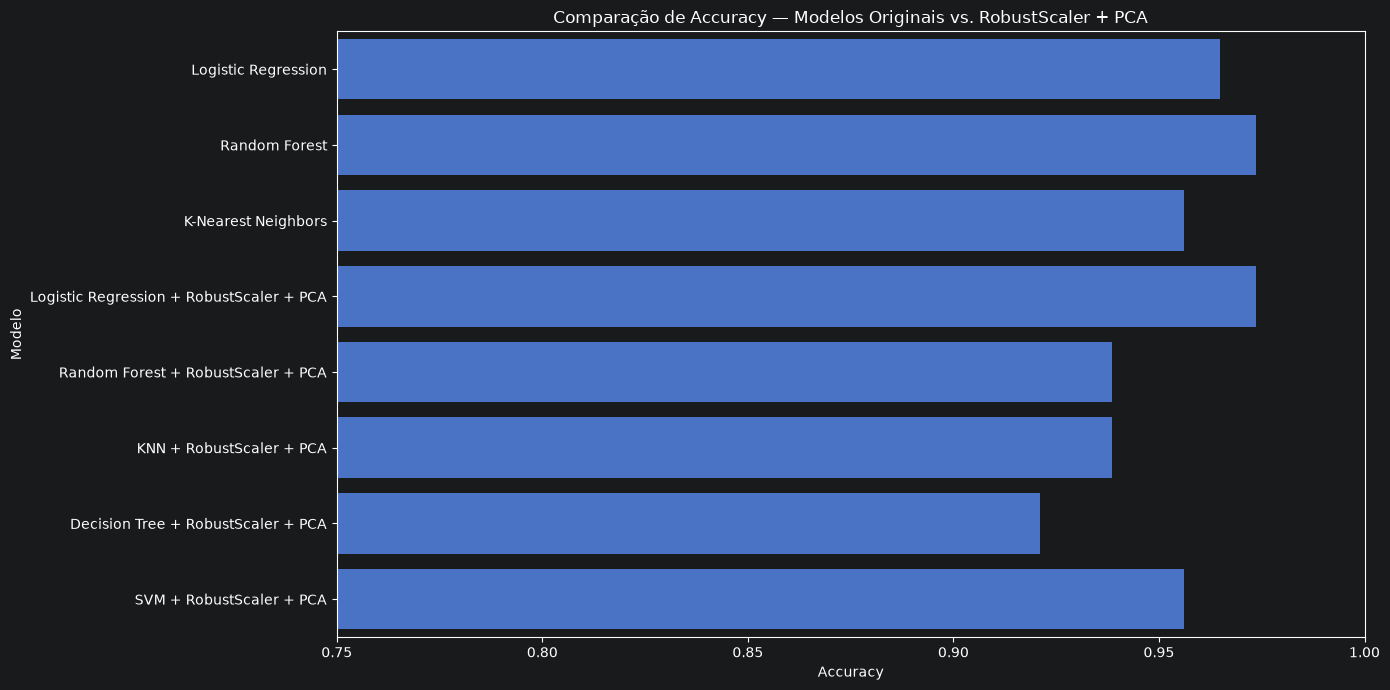

In [42]:
comparison_final = pd.DataFrame(results)

plt.figure(figsize=(14, 7))

sns.barplot(
    data=comparison_final,
    x="Accuracy",
    y="Model"
)

plt.title("Comparação de Accuracy — Modelos Originais vs. RobustScaler + PCA")
plt.xlabel("Accuracy")
plt.ylabel("Modelo")
plt.xlim(0.75, 1.0)

plt.tight_layout()
plt.show()

In [43]:
pca_comparison = comparison_final[
    comparison_final["Model"].str.contains("PCA")
].copy()

pca_comparison = pca_comparison.sort_values(
    "Accuracy",
    ascending=False
)

display(
    pca_comparison[
        ["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]
    ]
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Logistic Regression + RobustScaler + PCA,0.973684,1.000000,0.928571,0.962963,0.997354
7,SVM + RobustScaler + PCA,0.956140,0.974359,0.904762,0.938272,0.996032
4,Random Forest + RobustScaler + PCA,0.938596,0.948718,0.880952,0.913580,0.985450
5,KNN + RobustScaler + PCA,0.938596,0.972973,0.857143,0.911392,0.982308
6,Decision Tree + RobustScaler + PCA,0.921053,0.945946,0.833333,0.886076,0.902778


EXTRA - Visão computacional
